In [130]:
!pip install biopython networkx scipy pandas numpy matplotlib infomap scikit-learn seaborn 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [131]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns


from Bio.PDB import PDBParser
from scipy.spatial import cKDTree
from collections import Counter

In [132]:
nome_proteina = "1A3N"
PDB_FILES = ["data/raw/1A3N/1A3N.pdb"]

In [133]:
AA_CLASS = {

    # Hidrofóbicos
    "ALA":"hydrophobic",
    "VAL":"hydrophobic",
    "ILE":"hydrophobic",
    "LEU":"hydrophobic",
    "MET":"hydrophobic",
    "PHE":"hydrophobic",
    "TRP":"hydrophobic",
    "PRO":"hydrophobic",

    # Polares
    "SER":"polar",
    "THR":"polar",
    "ASN":"polar",
    "GLN":"polar",
    "TYR":"polar",
    "CYS":"polar",

    # Positivos
    "LYS":"positive",
    "ARG":"positive",
    "HIS":"positive",

    # Negativos
    "ASP":"negative",
    "GLU":"negative",

    # Glicina
    "GLY":"special"
}

In [134]:
def biochemical_similarity(res1, res2):

    c1 = AA_CLASS.get(res1, "other")
    c2 = AA_CLASS.get(res2, "other")

    if c1 == c2:
        return 1.0

    # atração eletrostática
    if (
        (c1 == "positive" and c2 == "negative")
        or
        (c1 == "negative" and c2 == "positive")
    ):
        return 0.9

    # polar-polar
    if (
        c1 == "polar"
        and
        c2 == "polar"
    ):
        return 0.8

    # hidrofóbico-polar
    if (
        c1 == "hydrophobic"
        and
        c2 == "polar"
    ) or (
        c2 == "hydrophobic"
        and
        c1 == "polar"
    ):
        return 0.3

    return 0.5

In [135]:
def load_residues(pdb_files):
    parser = PDBParser(QUIET=True)
    residues = []
    for pdb_file in pdb_files:
        structure = parser.get_structure(nome_proteina, pdb_file)
        for model in structure:
            for chain in model:
                for residue in chain:
                    if residue.id[0] != " ":
                        continue
                    if "CA" not in residue:
                        continue
                    ca = residue["CA"]
                    residues.append({
                        "node_id":
                        f"{chain.id}_{residue.id[1]}",
                        "chain":
                        chain.id,
                        "resname":
                        residue.resname,
                        "resid":
                        residue.id[1],
                        "x":
                        float(ca.coord[0]),
                        "y":
                        float(ca.coord[1]),
                        "z":
                        float(ca.coord[2])
                    })
    return pd.DataFrame(residues)

In [136]:
res_df = load_residues(PDB_FILES)
print("Resíduos:", len(res_df))
res_df.head()

Resíduos: 572


,node_id,chain,resname,resid,x,y,z
0,A_1,A,VAL,1,10.228,20.761000,6.807
1,A_2,A,LEU,2,6.624,21.451000,7.763
2,A_3,A,SER,3,4.831,23.237000,4.928
3,A_4,A,PRO,4,2.252,25.966000,5.311
4,A_5,A,ALA,5,-0.457,23.367001,4.513


In [137]:
def build_biophysical_graph(residues_df, cutoff, alpha, beta):

    G = nx.Graph()
    
    for row in residues_df.itertuples():
        G.add_node(
            row.node_id,
            chain=row.chain,
            residue=row.resname,
            resid=row.resid
        )
    
    coords = residues_df[
        ["x","y","z"]
    ].values

    node_ids = residues_df["node_id"].values
    residues = residues_df["resname"].values

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=cutoff)

    for i,j in pairs:
        distance = np.linalg.norm(coords[i]-coords[j])
        spatial_weight = np.exp(-distance/cutoff)
        bio_weight = biochemical_similarity(residues[i],residues[j])
        final_weight = (alpha*spatial_weight + beta*bio_weight)

        G.add_edge(
            node_ids[i],
            node_ids[j],
            distance=distance,
            spatial_weight=spatial_weight,
            bio_weight=bio_weight,
            weight=final_weight
        )

    return G

In [138]:
# Distância máxima para considerar uma interação (Angstroms)
cutoff=8.0
# alpha e beta definem o Peso da interação
alpha=0.2   # Distância Espacial
beta=0.8    # Similaridade Biofísica

G = build_biophysical_graph(res_df, cutoff, alpha, beta)

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

# Listar os nós com atributos
nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")
display(nodes_df.head())

# Listar as arestas com atributos
edges_df = pd.DataFrame([
    {"source": u, "target": v, **d}
    for u, v, d in G.edges(data=True)
])
display(edges_df.head())

Nós: 572
Arestas: 2828


,chain,residue,resid
A_1,A,VAL,1
A_2,A,LEU,2
A_3,A,SER,3
A_4,A,PRO,4
A_5,A,ALA,5


,source,target,distance,spatial_weight,bio_weight,weight
0,A_1,C_138,7.395008,0.396779,0.3,0.319356
1,A_1,A_3,6.228067,0.459090,0.3,0.331818
2,A_1,A_2,3.791945,0.622512,1.0,0.924502
3,A_1,C_139,7.642722,0.384681,0.5,0.476936
4,A_2,A_4,6.746251,0.430296,1.0,0.886059


In [139]:
degrees = [d for _,d in G.degree()]

print("="*60)
print("Grau médio:", np.mean(degrees))
print("Grau máximo:", np.max(degrees))
print("Densidade:", nx.density(G))
print(f"Conectividade: {nx.is_connected(G)}")
if nx.is_connected(G):
    print(f"Comprimento médio dos caminhos mais curtos: {nx.average_shortest_path_length(G):.2f}")
    print(f"Diâmetro: {nx.diameter(G)}")
print("="*60)

Grau médio: 9.888111888111888
Grau máximo: 17
Densidade: 0.017317183691964777
Conectividade: True
Comprimento médio dos caminhos mais curtos: 6.34
Diâmetro: 13


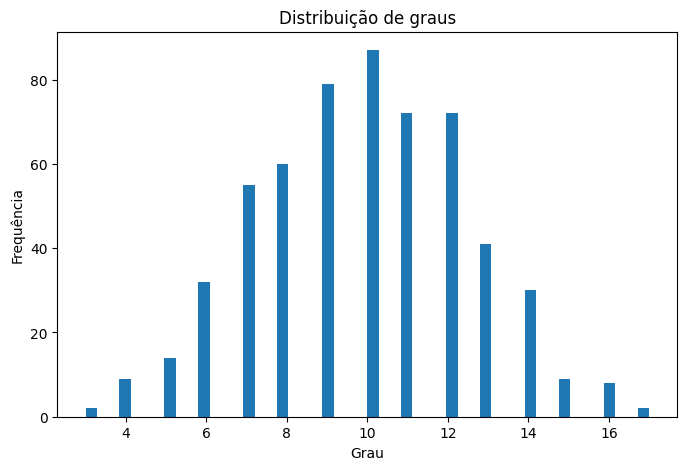

In [140]:
plt.figure(figsize=(8,5))
plt.hist(degrees, bins=50)
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.title("Distribuição de graus")
plt.show()

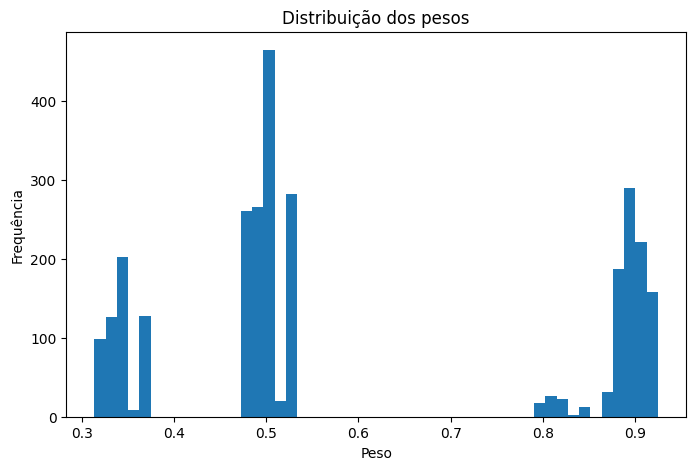

In [141]:
weights = [
    G[u][v]["weight"]
    for u,v in G.edges()
]

plt.figure(figsize=(8,5))

plt.hist(
    weights,
    bins=50
)

plt.xlabel("Peso")
plt.ylabel("Frequência")
plt.title("Distribuição dos pesos")

plt.show()

In [142]:
chain_counts = Counter(
    nx.get_node_attributes(
        G,
        "chain"
    ).values()
)

pd.DataFrame(
    chain_counts.items(),
    columns=["Chain","Residues"]
).sort_values("Chain")

,Chain,Residues
0,A,141
1,B,145
2,C,141
3,D,145


In [143]:
# Dados dos nós
degrees = dict(G.degree())
print("Degree Centrality: OK")
clustering = nx.clustering(G)
print("Clustering Centrality: OK")
closeness = nx.closeness_centrality(G)
print("Closeness Centrality: OK")
betweenness = nx.betweenness_centrality(G)
print("Betwenness  Centrality: OK")
#eigenvector = nx.eigenvector_centrality(G)
eigenvector = nx.eigenvector_centrality_numpy(G)
print("Eigenvetor Centrality: OK")
page_rank = nx.pagerank(G)
print("Pagerank Centrality: OK")

df_nos = pd.DataFrame({
    "node_id": list(G.nodes()),
    "grau": [degrees[n] for n in G.nodes()],
    "clustering": [clustering[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "page_rank": [page_rank[n] for n in G.nodes()]
})


Degree Centrality: OK
Clustering Centrality: OK
Closeness Centrality: OK
Betwenness  Centrality: OK
Eigenvetor Centrality: OK
Pagerank Centrality: OK


In [144]:
#df_nos.to_csv("outputs/"+nome_proteina+"_"+str(cutoff)+"_centralidades_nos.csv", index=False)

In [145]:
print("Estatísticas dos primeiros nós:")
print(df_nos.head().to_string(index=False))
print("="*60)
print("Dados das primeiras arestas:")
for u, v, data in list(G.edges(data=True))[:10]:
    print(f"{u}-{v} {data}")
print("="*60)

Estatísticas dos primeiros nós:
node_id  grau  clustering  closeness  betweenness  eigenvector  page_rank
    A_1     4    0.333333   0.160800     0.019191     0.001894   0.000862
    A_2     8    0.464286   0.164269     0.012465     0.006629   0.001697
    A_3     6    0.666667   0.154199     0.006600     0.003416   0.000990
    A_4     6    0.800000   0.146373     0.000270     0.003769   0.001321
    A_5     7    0.714286   0.151781     0.000465     0.006209   0.001229
Dados das primeiras arestas:
A_1-C_138 {'distance': np.float64(7.395007888239889), 'spatial_weight': np.float64(0.39677893743947185), 'bio_weight': 0.3, 'weight': np.float64(0.3193557874878944)}
A_1-A_3 {'distance': np.float64(6.228067445099491), 'spatial_weight': np.float64(0.4590902658469972), 'bio_weight': 0.3, 'weight': np.float64(0.33181805316939944)}
A_1-A_2 {'distance': np.float64(3.7919453682002717), 'spatial_weight': np.float64(0.622511503668646), 'bio_weight': 1.0, 'weight': np.float64(0.9245023007337293)}
A_

In [146]:
metricas = ["grau", "clustering", "closeness", "betweenness", "eigenvector", "page_rank"]
# Criar DataFrame com estatísticas descritivas lado a lado
df_stats = pd.DataFrame({m: df_nos[m].describe() for m in metricas})

print("="*60)
print("Estatísticas comparativas das métricas de centralidade")
display(df_stats)
print("="*60)

Estatísticas comparativas das métricas de centralidade


,grau,clustering,closeness,betweenness,eigenvector,page_rank
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,9.888112,0.544934,0.159360,0.009373,0.016556,0.001748
std,2.617080,0.120368,0.016598,0.010568,0.038428,0.000420
min,3.000000,0.300000,0.129010,0.000000,0.000059,0.000806
25%,8.000000,0.461538,0.145099,0.001350,0.000876,0.001457
50%,10.000000,0.514719,0.157235,0.005821,0.002528,0.001745
75%,12.000000,0.619048,0.173306,0.013324,0.013447,0.002030
max,17.000000,1.000000,0.196018,0.053210,0.269972,0.002865


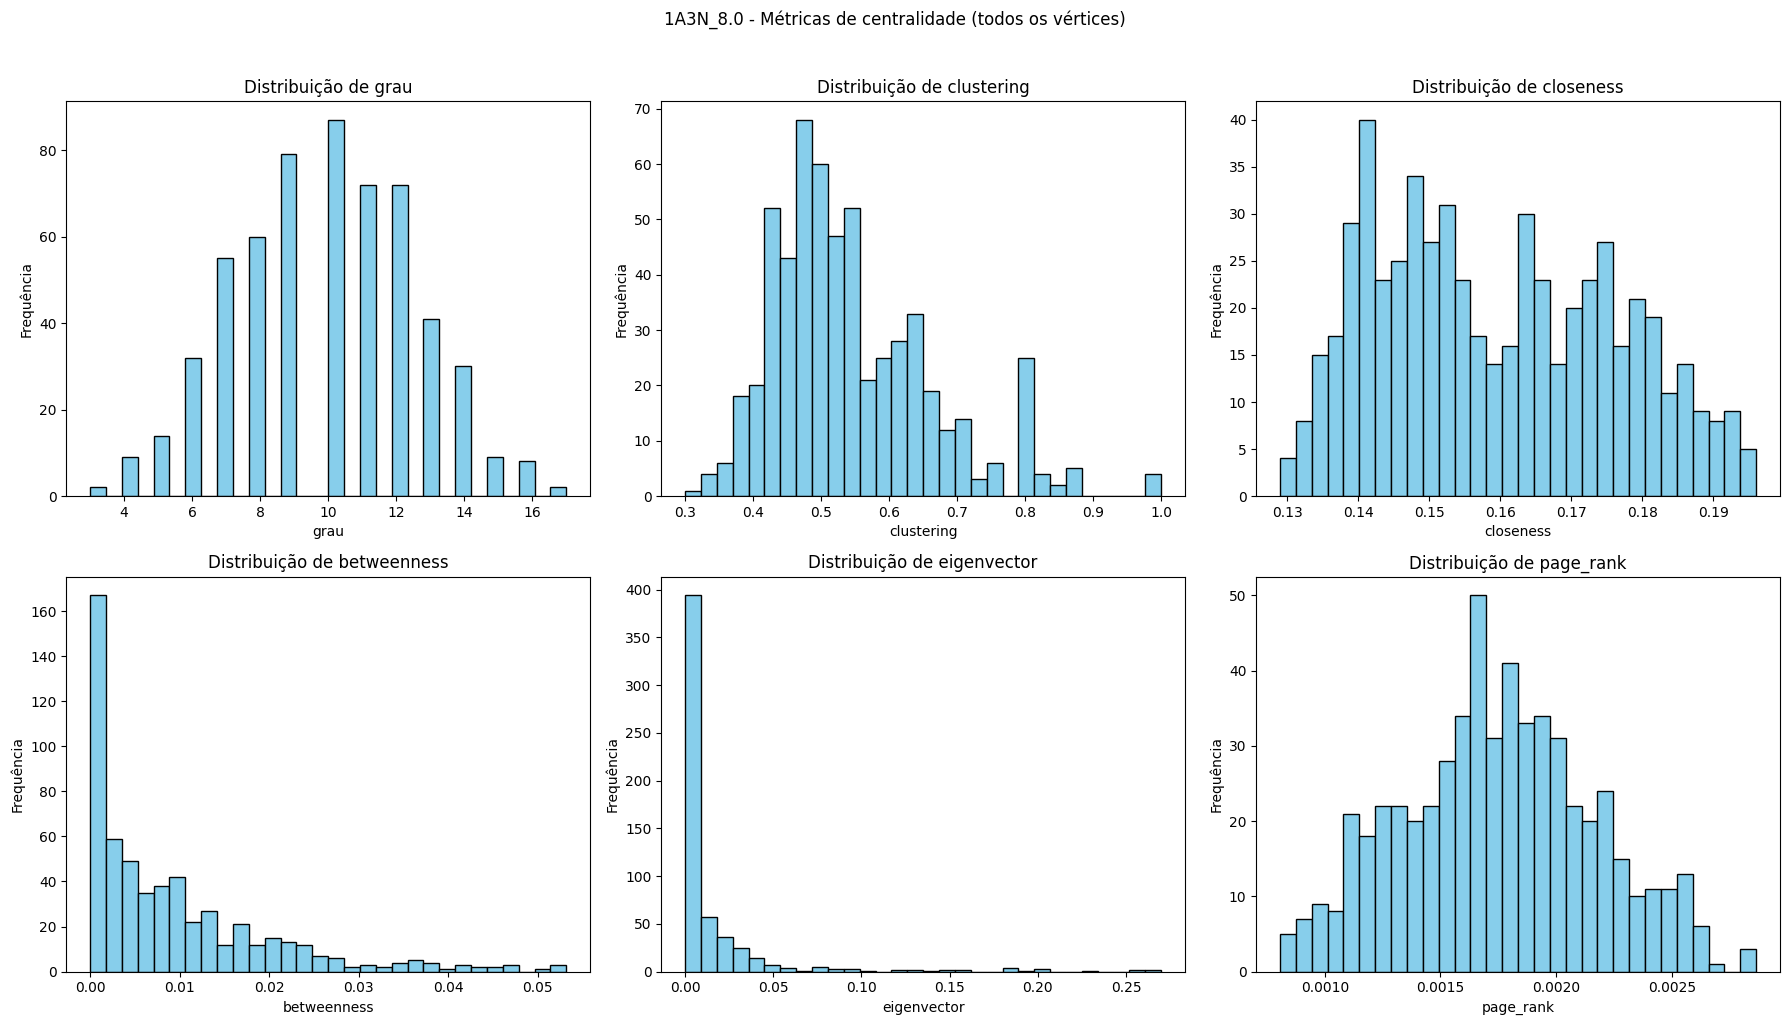

In [147]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # grid 2x3
axes = axes.flatten()

for i, metric in enumerate(metricas):
    axes[i].hist(df_nos[metric], bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuição de {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frequência")
    
plt.suptitle(nome_proteina+"_"+str(cutoff)+" - Métricas de centralidade (todos os vértices)", y=1.02)
plt.tight_layout()
plt.show()

,grau,clustering,closeness,betweenness,eigenvector,page_rank
grau,1.00,-0.70,0.43,0.39,0.28,0.86
clustering,-0.70,1.00,-0.60,-0.61,-0.07,-0.64
closeness,0.43,-0.60,1.00,0.79,-0.04,0.31
betweenness,0.39,-0.61,0.79,1.00,-0.01,0.30
eigenvector,0.28,-0.07,-0.04,-0.01,1.00,0.19
page_rank,0.86,-0.64,0.31,0.30,0.19,1.00


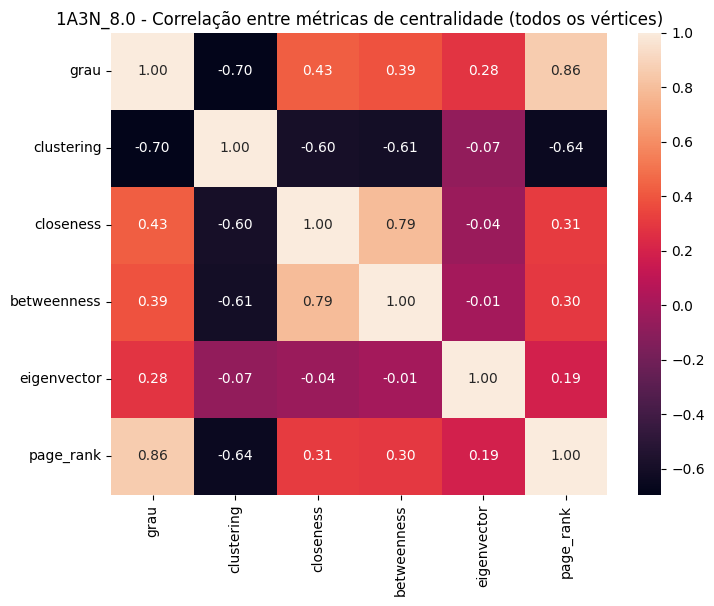

In [148]:
# Matriz de correlação entre todas as métricas
corr = df_nos[metricas].corr()
display(corr.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title(nome_proteina+"_"+str(cutoff)+" - Correlação entre métricas de centralidade (todos os vértices)")
plt.show()



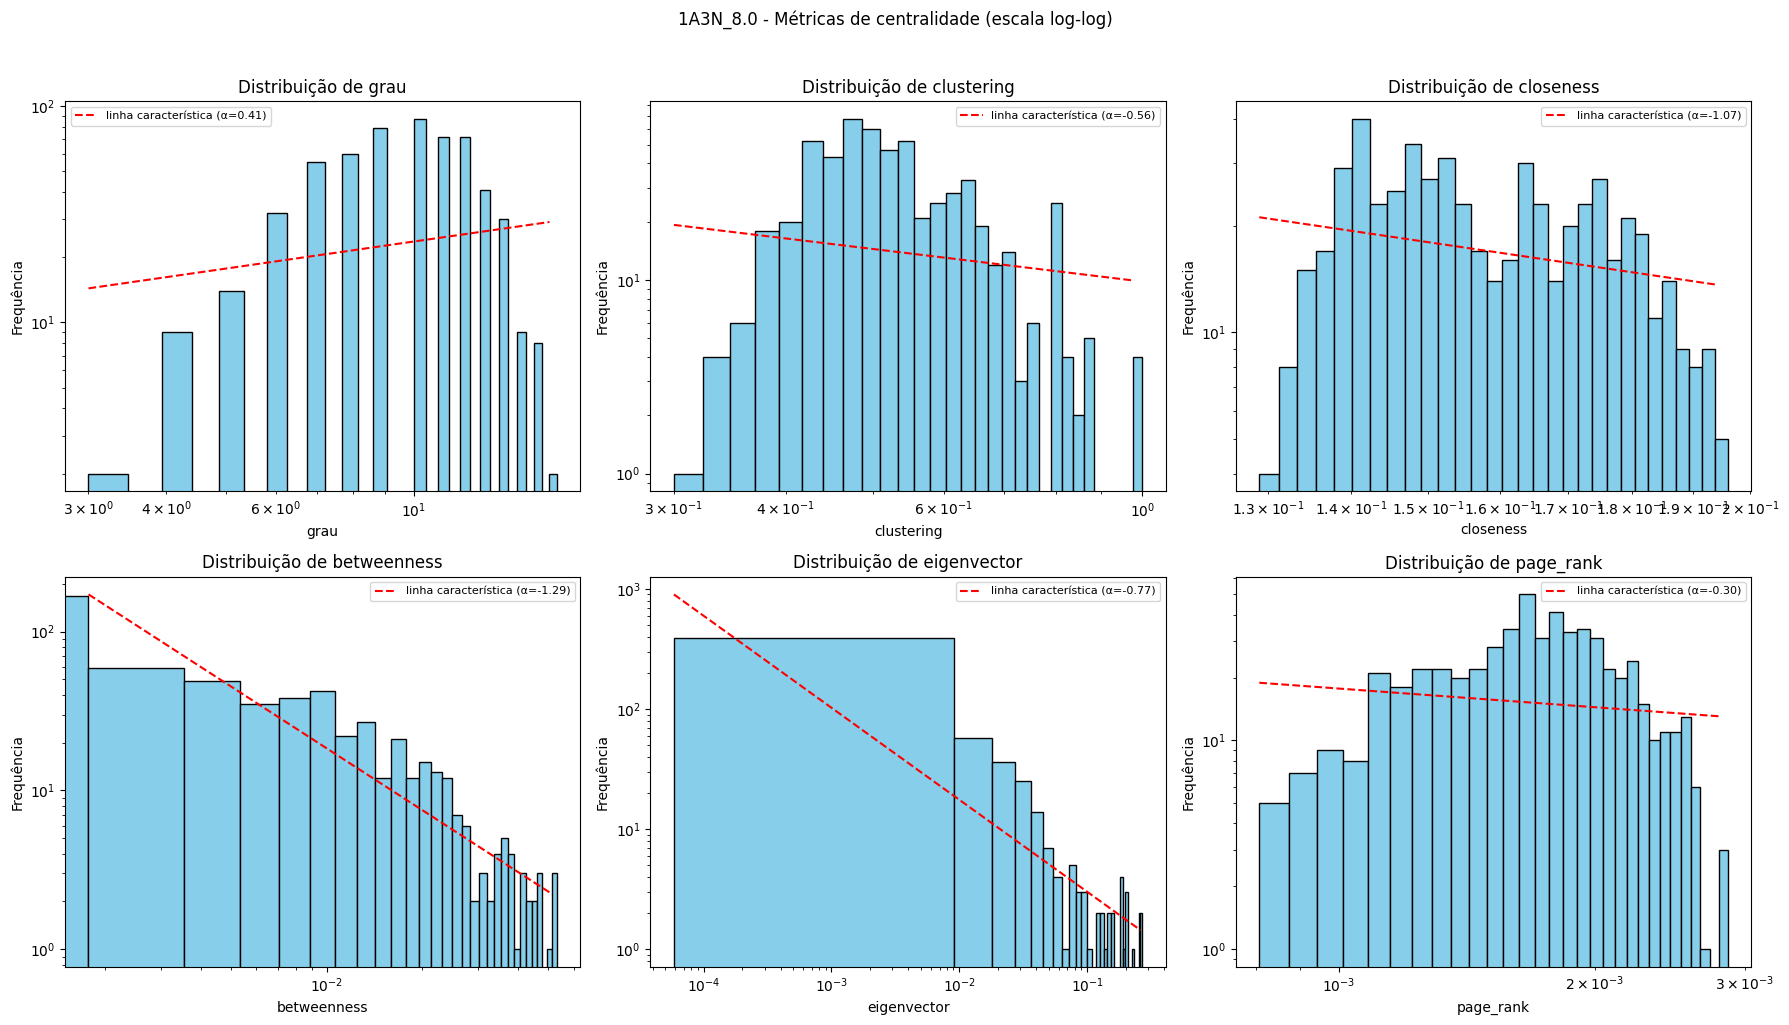

In [149]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # grid 2x3
axes = axes.flatten()

for i, metric in enumerate(metricas):
    valores = df_nos[metric]
    
    # Histograma
    counts, bins, _ = axes[i].hist(valores, bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuição de {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frequência")
    
    # Escala log-log
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")
    
    # Linha característica (ajuste linear em log-log)
    mask = (counts > 0) & (bins[:-1] > 0)  # filtrar valores válidos
    x = bins[:-1][mask]
    y = counts[mask]
    
    if len(x) > 2:  # só ajusta se houver pontos suficientes
        logx = np.log10(x)
        logy = np.log10(y)
        
        try:
            coef = np.polyfit(logx, logy, 1)  # ajuste linear em log-log
            fitted = 10**(coef[1]) * x**coef[0]
            axes[i].plot(x, fitted, "r--", label=f"linha característica (α={coef[0]:.2f})")
            axes[i].legend(fontsize=8)
        except np.linalg.LinAlgError:
            # Se o ajuste não convergir, apenas pula
            pass


plt.suptitle(nome_proteina+"_"+str(cutoff)+" - Métricas de centralidade (escala log-log)", y=1.02)
plt.tight_layout()
plt.show()


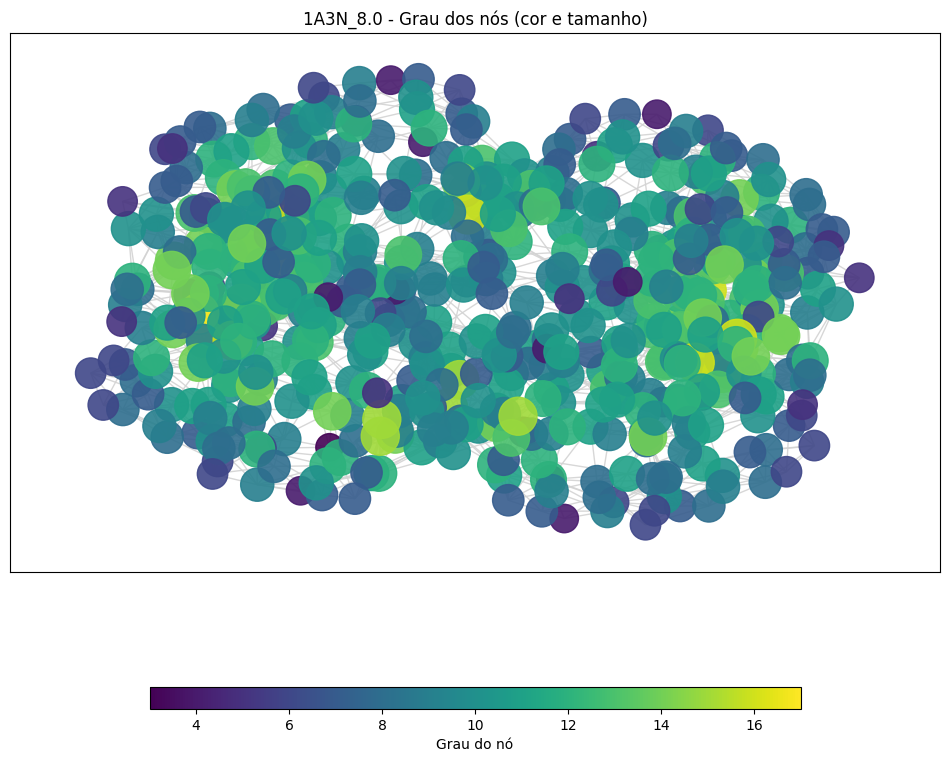

In [150]:
graus = df_nos["grau"]

# Normalização dos valores de grau
norm = plt.Normalize(vmin=graus.min(), vmax=graus.max())

# Cores baseadas no grau
cores = plt.cm.viridis(norm(graus))

# Tamanho proporcional ao grau
node_sizes = [300 + g*30 for g in graus] 

# Criar dicionário de posições para o layout
pos = {}
for _, linha in res_df.iterrows():
    pos[linha["node_id"]] = (
        linha["x"],
        linha["y"]
    )

plt.figure(figsize=(12,10))
ax = plt.gca()

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=ax
)

plt.title(nome_proteina+"_"+str(cutoff)+" - Grau dos nós (cor e tamanho)")

# Barra de cores para interpretação
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
plt.colorbar(
    sm,
    ax=ax,
    label="Grau do nó",
    shrink=0.7,
    aspect=30,
    orientation="horizontal"
)

plt.show()


In [151]:
from scipy.sparse import csgraph

A = nx.to_numpy_array(G, weight="weight")
print(A.shape)

L = csgraph.laplacian(A, normed=False)
print(L.shape)

L_norm = csgraph.laplacian(A, normed=True)
print(L_norm.shape)

(572, 572)
(572, 572)
(572, 572)


In [152]:
from scipy.sparse.linalg import eigsh

eigenvalues, eigenvectors = eigsh(
    L_norm,
    k=10,
    which="SM"
)

print(eigenvalues)

[6.20796270e-17 1.06322614e-02 1.78453826e-02 2.86500725e-02
 4.10743265e-02 4.58923183e-02 5.21525434e-02 5.46946309e-02
 6.41866910e-02 6.91473369e-02]


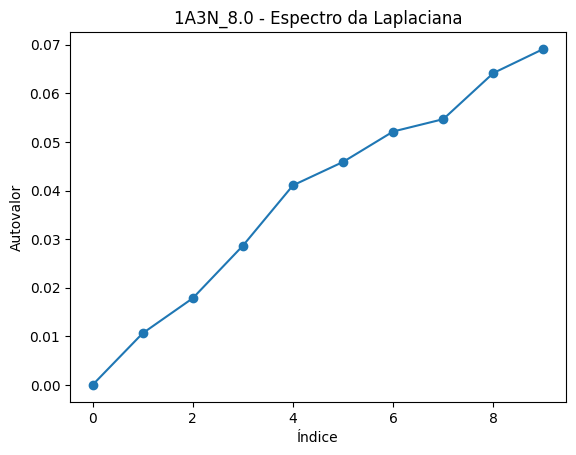

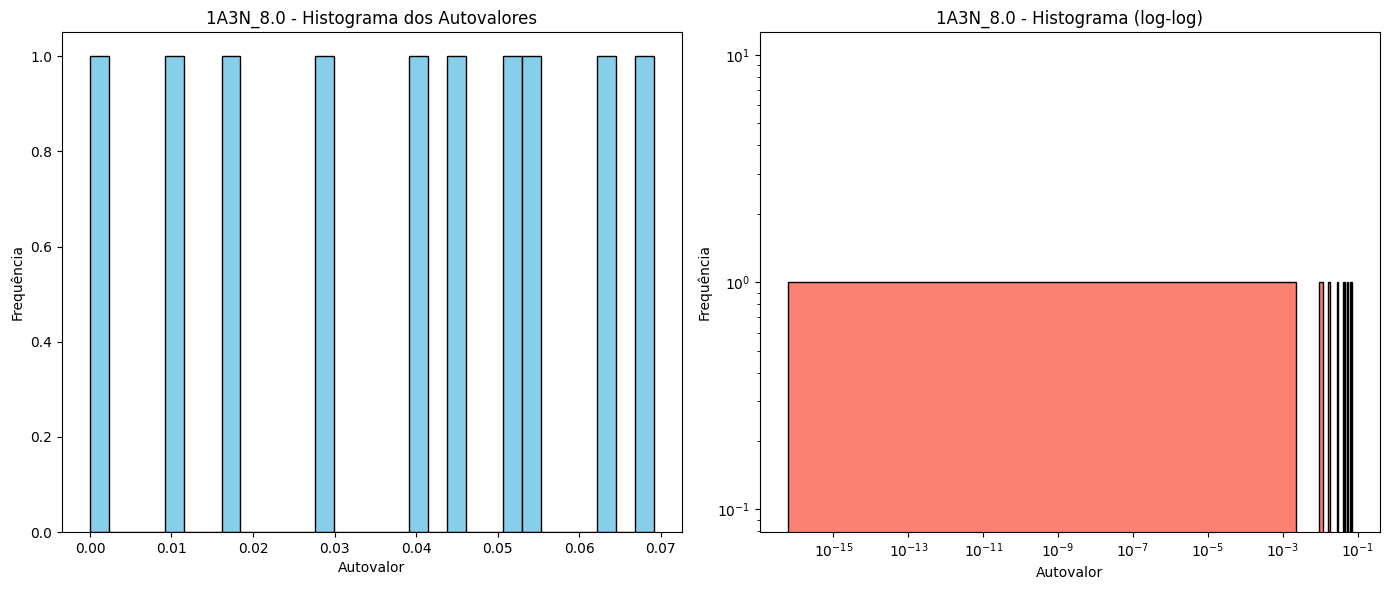

In [153]:
# Espectro da Laplaciana
plt.plot(sorted(eigenvalues), 'o-')
plt.title(nome_proteina+"_"+str(cutoff)+" - Espectro da Laplaciana")
plt.xlabel("Índice")
plt.ylabel("Autovalor")
plt.show()

# Subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Histograma dos Autovalores ---
axes[0].hist(eigenvalues, bins=30, color="skyblue", edgecolor="black")
axes[0].set_title(nome_proteina+"_"+str(cutoff)+" - Histograma dos Autovalores")
axes[0].set_xlabel("Autovalor")
axes[0].set_ylabel("Frequência")

# --- Histograma dos Autovalores em escala log-log ---
axes[1].hist(eigenvalues, bins=30, color="salmon", edgecolor="black")
axes[1].set_title(nome_proteina+"_"+str(cutoff)+" - Histograma (log-log)")
axes[1].set_xlabel("Autovalor")
axes[1].set_ylabel("Frequência")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


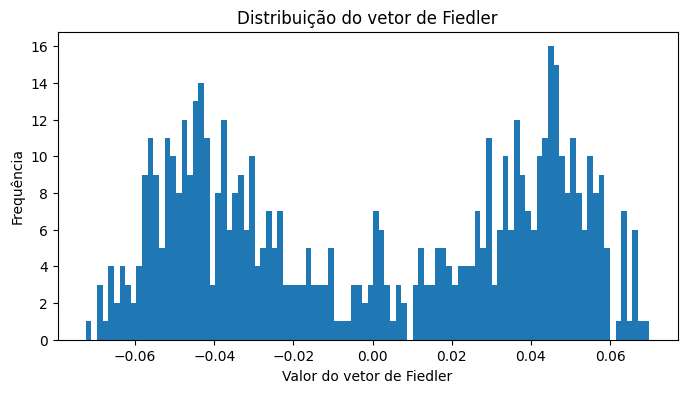

In [154]:
fiedler = eigenvectors[:,1]
plt.figure(figsize=(8,4))

plt.hist(
    fiedler,
    bins=100
)

plt.xlabel("Valor do vetor de Fiedler")
plt.ylabel("Frequência")

plt.title("Distribuição do vetor de Fiedler")

plt.show()

In [155]:
nodes = list(G.nodes())

spectral_partition = pd.DataFrame({

    "node_id": nodes,

    "spectral_group":
    (fiedler > 0).astype(int)

})

spectral_partition.head()

,node_id,spectral_group
0,A_1,0
1,A_2,0
2,A_3,0
3,A_4,0
4,A_5,0


In [156]:
spectral_partition[
    "spectral_group"
].value_counts()

spectral_group
1    291
0    281
Name: count, dtype: int64

In [157]:
nodes = pd.DataFrame({

    "node_id": list(G.nodes()),

    "chain": [
        G.nodes[n]["chain"]
        for n in G.nodes()
    ],

    "spectral_group":
    (fiedler > 0).astype(int)
})

pd.crosstab(
    nodes["chain"],
    nodes["spectral_group"]
)

spectral_group,0,1
chain,,
A,131,10
B,145,0
C,5,136
D,0,145


Vetor de Fiedler:
[-0.0128 -0.0339 -0.0251 -0.0321 -0.032  -0.0442 -0.0437 -0.0356 -0.0439
 -0.054  -0.0412 -0.0424 -0.0574 -0.0524 -0.0387 -0.0341 -0.0461 -0.0386
 -0.0351 -0.0374 -0.0512 -0.0511 -0.0464 -0.0451 -0.052  -0.0502 -0.0462
 -0.0514 -0.0496 -0.0441 -0.0461 -0.0431 -0.0369 -0.0433 -0.0423 -0.0327
 -0.0229 -0.0023 -0.0111 -0.0109 -0.0011 -0.0032 -0.0138 -0.0142 -0.0159
 -0.0263 -0.0278 -0.0337 -0.0263 -0.0274 -0.0289 -0.0357 -0.03   -0.0335
 -0.0479 -0.0488 -0.0391 -0.0442 -0.0544 -0.0523 -0.0423 -0.0438 -0.0479
 -0.0417 -0.0393 -0.0395 -0.0321 -0.031  -0.0425 -0.0434 -0.0299 -0.0314
 -0.0342 -0.022  -0.0257 -0.0337 -0.0227 -0.0165 -0.0279 -0.0288 -0.0144
 -0.0133 -0.0112 -0.0099 -0.005  -0.0037 -0.0021  0.0007  0.0021  0.0032
  0.002   0.007   0.001   0.0038 -0.0098 -0.012  -0.0122 -0.0203 -0.0253
 -0.0299 -0.0382 -0.0335 -0.0376 -0.039  -0.0491 -0.0503 -0.0593 -0.0447
 -0.0547 -0.0663 -0.0666 -0.0483 -0.058  -0.0555 -0.0393 -0.0383 -0.0636
 -0.0328 -0.0531 -0.0533 -0.0565 

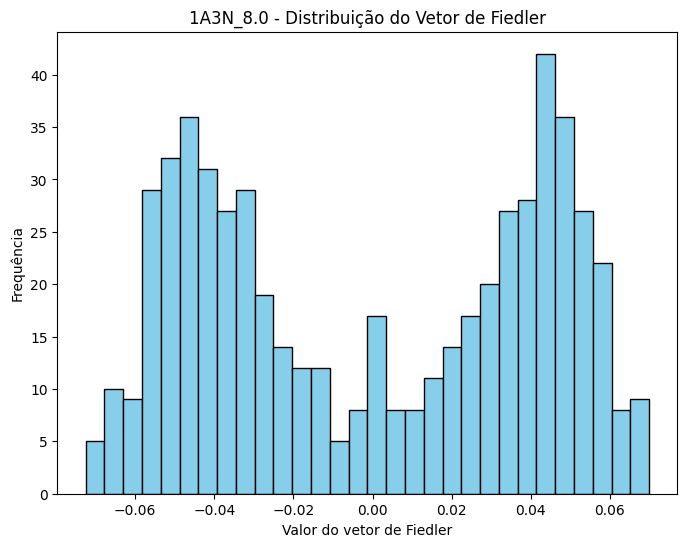

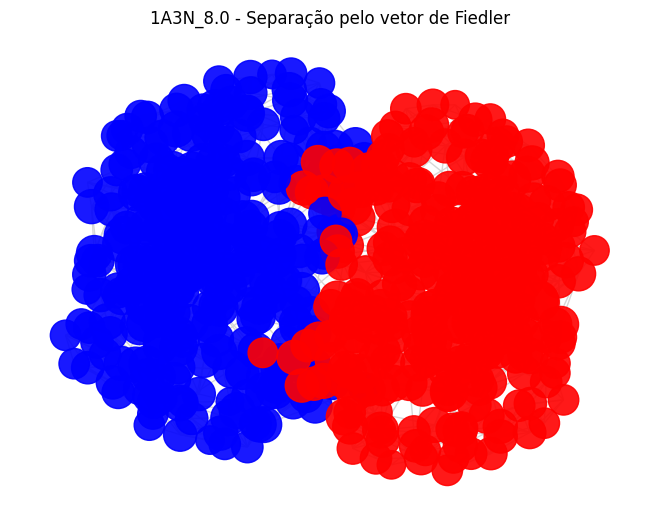

In [158]:
print("Vetor de Fiedler:")
print(np.round(fiedler,4))

# Histograma da distribuição dos valores do vetor de Fiedler
plt.figure(figsize=(8,6))
plt.hist(fiedler, bins=30, color="skyblue", edgecolor="black")
plt.title(nome_proteina+"_"+str(cutoff)+" - Distribuição do Vetor de Fiedler")
plt.xlabel("Valor do vetor de Fiedler")
plt.ylabel("Frequência")
plt.show()


colors = ['red' if v>0 else 'blue' for v in fiedler]
nx.draw(G,
        pos=pos,
        node_size=node_sizes,
        node_color=colors,
        with_labels=False,
        font_size=7,
        edge_color="lightgray",
        alpha=0.9,
        )
plt.title(nome_proteina+"_"+str(cutoff)+" - Separação pelo vetor de Fiedler")
plt.show()

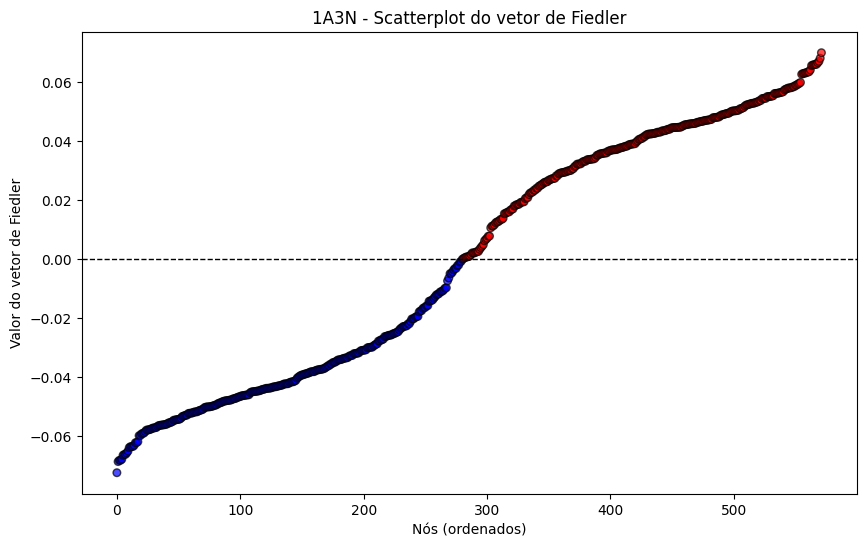

In [159]:
import numpy as np
import matplotlib.pyplot as plt

# Ordena os valores do vetor de Fiedler
sorted_indices = np.argsort(fiedler)
sorted_values = fiedler[sorted_indices]

# Scatterplot 2D
plt.figure(figsize=(10,6))
plt.scatter(range(len(sorted_values)), sorted_values,
            c=["red" if v > 0 else "blue" for v in sorted_values],
            alpha=0.7, edgecolor="black", s=30)

plt.axhline(0, color="black", linestyle="--", linewidth=1)  # linha de separação
plt.title(nome_proteina + " - Scatterplot do vetor de Fiedler")
plt.xlabel("Nós (ordenados)")
plt.ylabel("Valor do vetor de Fiedler")
plt.show()


In [160]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import modularity

louvain_comms = louvain_communities(
    G,
    weight="weight",
    seed=42
)

print("Comunidades:", len(louvain_comms))

Q_louvain = modularity(
    G,
    louvain_comms,
    weight="weight"
)

print("Modularidade:", Q_louvain)

Comunidades: 14
Modularidade: 0.7763812451627713


In [161]:
louvain_membership = {}

for cid, community in enumerate(louvain_comms):

    for node in community:

        louvain_membership[node] = cid

louvain_df = pd.DataFrame({

    "node_id":
    list(louvain_membership.keys()),

    "louvain":
    list(louvain_membership.values())
})

louvain_df.head()

,node_id,louvain
0,A_5,0
1,A_17,0
2,A_134,0
3,A_1,0
4,A_124,0


In [162]:
pd.Series(
    louvain_membership
).value_counts().sort_values(
    ascending=False
).head(20)

1     61
7     60
4     52
11    52
13    50
6     49
0     38
8     36
9     35
2     34
12    29
3     28
10    25
5     23
Name: count, dtype: int64

In [163]:
from infomap import Infomap

im = Infomap()

node_to_int = {
    node:i
    for i,node in enumerate(G.nodes())
}

int_to_node = {
    i:node
    for node,i in node_to_int.items()
}

for u,v,data in G.edges(data=True):

    im.add_link(
        node_to_int[u],
        node_to_int[v],
        float(data["weight"])
    )

im.run()

print(
    "Comunidades:",
    im.num_top_modules
)

Comunidades: 3


In [164]:
infomap_membership = {}

for node in im.nodes:

    infomap_membership[
        int_to_node[node.node_id]
    ] = node.module_id

infomap_df = pd.DataFrame({

    "node_id":
    list(infomap_membership.keys()),

    "infomap":
    list(infomap_membership.values())
})

pd.Series(
    infomap_membership
).value_counts().sort_values(
    ascending=False
).head(20)

1    290
2    162
3    120
Name: count, dtype: int64

In [165]:
truth = {}

for node in G.nodes():

    chain = G.nodes[node]["chain"]

    if chain in list("AC"):
        truth[node] = "Alpha"

    elif chain in list("BD"):
        truth[node] = "Beta"


In [166]:
truth_df = pd.DataFrame({

    "node_id":
    list(truth.keys()),

    "truth":
    list(truth.values())
})

truth_df.head()

,node_id,truth
0,A_1,Alpha
1,A_2,Alpha
2,A_3,Alpha
3,A_4,Alpha
4,A_5,Alpha


In [167]:
eval_louvain = truth_df.merge(
    louvain_df,
    on="node_id"
)

eval_louvain.head()

,node_id,truth,louvain
0,A_1,Alpha,0
1,A_2,Alpha,0
2,A_3,Alpha,0
3,A_4,Alpha,0
4,A_5,Alpha,0


In [168]:
eval_infomap = truth_df.merge(
    infomap_df,
    on="node_id"
)

eval_infomap.head()

,node_id,truth,infomap
0,A_1,Alpha,1
1,A_2,Alpha,1
2,A_3,Alpha,1
3,A_4,Alpha,1
4,A_5,Alpha,1


In [169]:
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score
)

nmi_louvain = normalized_mutual_info_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

ari_louvain = adjusted_rand_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

print("NMI Louvain =", nmi_louvain)
print("ARI Louvain =", ari_louvain)

nmi_infomap = normalized_mutual_info_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

ari_infomap = adjusted_rand_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

print("NMI Infomap =", nmi_infomap)
print("ARI Infomap =", ari_infomap)

NMI Louvain = 0.3579429054234024
ARI Louvain = 0.13973085002564503
NMI Infomap = 0.25824775067380223
ARI Infomap = 0.1714056157795741


In [170]:
import numpy as np
from sklearn.metrics.cluster import contingency_matrix

def purity_score(
    y_true,
    y_pred
):

    cm = contingency_matrix(
        y_true,
        y_pred
    )

    return np.sum(
        np.max(cm, axis=0)
    ) / np.sum(cm)

purity_louvain = purity_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

print(
    "Purity Louvain =",
    purity_louvain
)

purity_infomap = purity_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

print(
    "Purity Infomap =",
    purity_infomap
)

Purity Louvain = 0.951048951048951
Purity Infomap = 0.7132867132867133


In [171]:
louvain_vs_truth = pd.crosstab(
    eval_louvain["truth"],
    eval_louvain["louvain"]
)
louvain_vs_truth.style.background_gradient(
    cmap="Blues"
)

louvain,0,1,2,3,4,5,6,7,8,9,10,11,12,13
truth,,,,,,,,,,,,,,
Alpha,38,61,32,1,0,9,0,59,34,35,0,0,13,0
Beta,0,0,2,27,52,14,49,1,2,0,25,52,16,50


In [172]:
infomap_vs_truth = pd.crosstab(
    eval_infomap["truth"],
    eval_infomap["infomap"]
)

infomap_vs_truth.style.background_gradient(
    cmap="Blues"
)

infomap,1,2,3
truth,,,
Alpha,142,21,119
Beta,148,141,1


In [173]:
louvain_chain_comm_df = pd.DataFrame({

    "node_id": list(louvain_membership.keys()),

    "community": list(louvain_membership.values()),

    "chain": [
        G.nodes[node]["chain"]
        for node in louvain_membership.keys()
    ]
})

louvain_chain_vs_comm = pd.crosstab(
    louvain_chain_comm_df["chain"],
    louvain_chain_comm_df["community"]
)

louvain_chain_vs_comm.style.background_gradient(
    cmap="Blues"
)

community,0,1,2,3,4,5,6,7,8,9,10,11,12,13
chain,,,,,,,,,,,,,,
A,38,61,32,1,0,9,0,0,0,0,0,0,0,0
B,0,0,0,27,52,14,49,1,2,0,0,0,0,0
C,0,0,0,0,0,0,0,59,34,35,0,0,13,0
D,0,0,2,0,0,0,0,0,0,0,25,52,16,50


In [174]:
infomap_chain_comm_df = pd.DataFrame({

    "node_id": list(infomap_membership.keys()),

    "community": list(infomap_membership.values()),

    "chain": [
        G.nodes[node]["chain"]
        for node in infomap_membership.keys()
    ]
})

infomap_chain_vs_comm = pd.crosstab(
    infomap_chain_comm_df["chain"],
    infomap_chain_comm_df["community"]
)

infomap_chain_vs_comm.style.background_gradient(
    cmap="Blues"
)

community,1,2,3
chain,,,
A,141,0,0
B,144,0,1
C,1,21,119
D,4,141,0


In [175]:
louvain_dominant_comm = louvain_chain_vs_comm.idxmax(axis=1)
louvain_dominant_comm

chain
A     1
B     4
C     7
D    11
dtype: int64

In [176]:
infomap_dominant_comm = infomap_chain_vs_comm.idxmax(axis=1)
infomap_dominant_comm

chain
A    1
B    1
C    3
D    2
dtype: int64

In [177]:
louvain_dominant_count = louvain_chain_vs_comm.max(axis=1)

pd.DataFrame({
    "community": louvain_dominant_comm,
    "residues": louvain_dominant_count
})

,community,residues
chain,,
A,1,61
B,4,52
C,7,59
D,11,52


In [178]:
infomap_dominant_count = infomap_chain_vs_comm.max(axis=1)

pd.DataFrame({
    "community": infomap_dominant_comm,
    "residues": infomap_dominant_count
})

,community,residues
chain,,
A,1,141
B,1,144
C,3,119
D,2,141


In [179]:
louvain_chain_purity = (
    louvain_chain_vs_comm.max(axis=1)
    /
    louvain_chain_vs_comm.sum(axis=1)
)

louvain_chain_purity.sort_values(
    ascending=False
)

chain
A    0.432624
C    0.418440
B    0.358621
D    0.358621
dtype: float64

In [180]:
infomap_chain_purity = (
    infomap_chain_vs_comm.max(axis=1)
    /
    infomap_chain_vs_comm.sum(axis=1)
)

infomap_chain_purity.sort_values(
    ascending=False
)

chain
A    1.000000
B    0.993103
D    0.972414
C    0.843972
dtype: float64

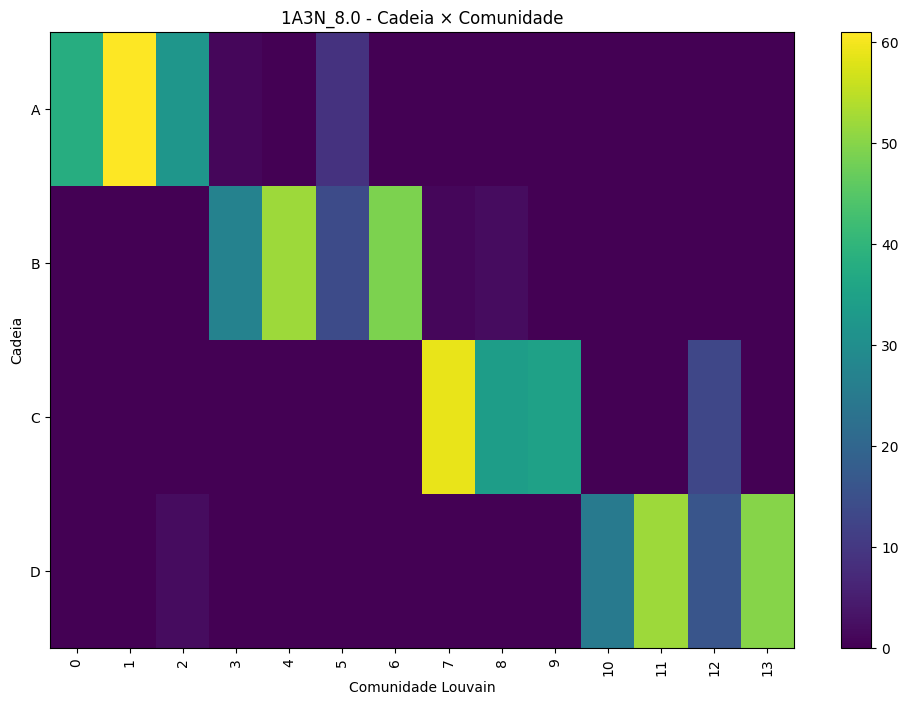

In [181]:
plt.figure(figsize=(12,8))

plt.imshow(
    louvain_chain_vs_comm,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(louvain_chain_vs_comm.shape[1]),
    louvain_chain_vs_comm.columns,
    rotation=90
)

plt.yticks(
    range(louvain_chain_vs_comm.shape[0]),
    louvain_chain_vs_comm.index
)

plt.xlabel("Comunidade Louvain")
plt.ylabel("Cadeia")

plt.title(nome_proteina+"_"+str(cutoff)+" - Cadeia × Comunidade")

plt.show()

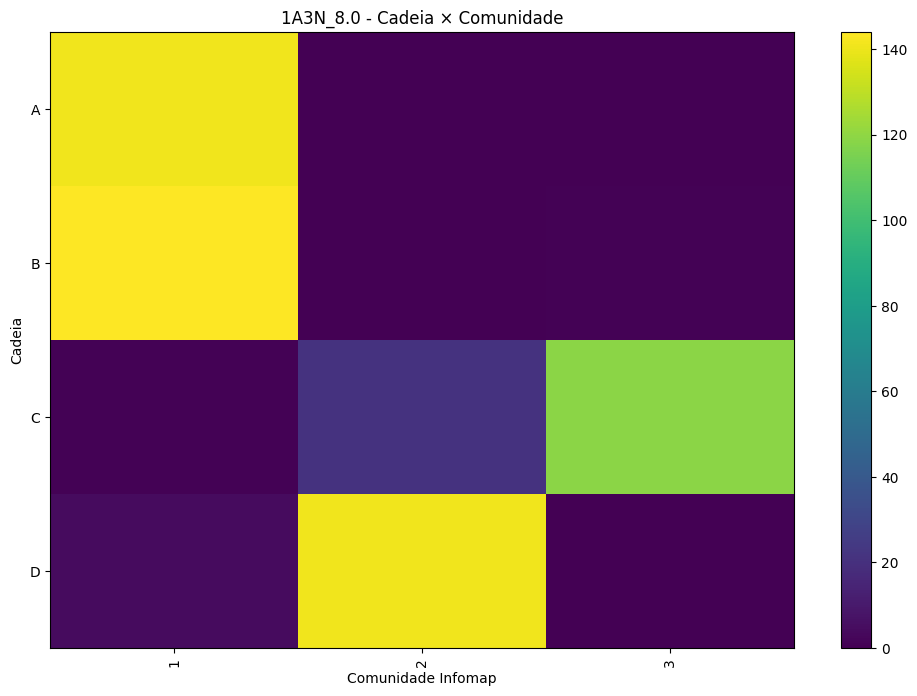

In [182]:
plt.figure(figsize=(12,8))

plt.imshow(
    infomap_chain_vs_comm,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(infomap_chain_vs_comm.shape[1]),
    infomap_chain_vs_comm.columns,
    rotation=90
)

plt.yticks(
    range(infomap_chain_vs_comm.shape[0]),
    infomap_chain_vs_comm.index
)

plt.xlabel("Comunidade Infomap")
plt.ylabel("Cadeia")

plt.title(nome_proteina+"_"+str(cutoff)+" - Cadeia × Comunidade")

plt.show()